# Fire impacts simulations

This notebook demonstrates the fire impacts simulation modules.

It is assumed that you have a `FireImpactsProject` populated with all pre-processed data for the catchment.

In [1]:
import logging
logging.basicConfig(level=logging.INFO,format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

from fire_impacts.sim import rusle, aggregate_rainfall_data, debris_flow
from fire_impacts.stochastic.rainfall import get_rainfall_replicates
from fire_impacts import FireImpactsProject

import matplotlib.pyplot as plt

2026-04-17 11:21:36,267 - numexpr.utils - INFO - Note: NumExpr detected 22 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
2026-04-17 11:21:36,268 - numexpr.utils - INFO - NumExpr defaulting to 16 threads.


## Load project

In [2]:
#proj = FireImpactsProject('.',exist_ok=True)
proj = FireImpactsProject('\\zz_TempDump\\fire_impacts_example_project', exist_ok=True)

In [3]:
proj.catchments

['EgSmallCatchment_7899']

> **Note:** You can capture multiple study areas / catchments within a single `FireImpactsProject` directory structure. Here we will assume you have one, so we will take the first (presumed only)

In [4]:
catchment_name = proj.catchments[0]
catchment_name

'EgSmallCatchment_7899'

In [5]:
subcatch_path = '..\\test_data\\Subcatchments_EgSmall_7899.shp'
#proj.add_subcatchments(catchment_name, subcatch_path)

## Rainfall data

Both the erosion (RUSLE) and debris flow modules rely on subdaily rainfall data. The erosion modules, demonstrated here, rely on 30 minute data, while the debris flow relies on 12 minute data.

Furthermore, it is encouraged that both modules be run stochastically, using multiple rainfall replicates.

The library provides functionality for processing stochastic rainfall data, generated by [pyraingen](https://github.com/crdykman/pyraingen). You can install pyraingen locally and calibrate it to available subdaily rainfall observations. Alternatively, you can call a remote pyraingen API and generate data based on publicly available data. We wil use the remote API in this example.

In [6]:
rain_data_start = '2019-03-07'
rain_data_end = '2021-04-01'

replicates = get_rainfall_replicates(proj,None, rain_data_start, rain_data_end, 10, 
                                     600, # mean annual rainfall (mm)
                                     20,  # mean temperature (C)
                                     2)   # num_years
rainfall_data= replicates[catchment_name]

2026-04-17 11:21:40,841 - fire_impacts.pre.project - INFO - Processing 1 catchments
C:\Users\richard.farr\OneDrive - Alluvium Consulting Australia\Documents\WorkItems\Projects\0124114_Bushfire_WQ_Modelling\WaterRA_Bushfire_Modeling\fire_impacts\stochastic\rainfall\replicates.py:111: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = boundary.geometry.centroid
2026-04-17 11:21:57,770 - fire_impacts.stochastic.rainfall.replicates - WARNING - Stochastic rainfall data ends at 2021-03-05, which is before the requested end date 2021-04-01. The generated num_years=2 may be too short to cover the full requested period. Downstream aggregation will be truncated.


Once we have our pyraingen rainfall replicates, we use `aggregate_rainfall_data()` to resample the results to the 30-minute frequency required for debris flow simulations

In [7]:
aggregate_rainfall_data?

Signature:
aggregate_rainfall_data(
    source,
    rain_data_start=None,
    rain_data_end=None,
    time_res='30min',
)
Docstring:
Aggregates subdaily stochastic rainfall data from a netCDF file to a specified time resolution.

Input data is expected to be rainfall replicates (eg from pyraingen), with data stored by simulation x day x subday,
 or simulation x time. If the input data is in day x subday format, it is first flattened to a long time series per simulation.

Returned dataframe is simulation (columns) x time (rows), with rainfall values aggregated to the specified time resolution.

If the rainfall units are in mm, the aggregation is done by summing the rainfall over the time period.
If the rainfall units are in mm/h, the aggregation is done by averaging the rainfall over the time period.

Parameters:
- source (str or xarray.Dataset): Path to the netCDF file containing rainfall data or an xarray Dataset.
- rain_data_start (datetime): Start date for the rainfall data.
- rain_

In [8]:
rainfall_30min = aggregate_rainfall_data(rainfall_data,rain_data_start,rain_data_end)

In [9]:
# You can inspect the aggregated rainfal data object if required:
rainfall_30min

<xarray.Dataset> Size: 3MB
Dimensions:    (time: 35040, replicate: 10)
Coordinates:
  * replicate  (replicate) object 80B 'Simulation_0' ... 'Simulation_9'
  * time       (time) datetime64[ns] 280kB 2019-03-07 ... 2021-03-05T23:30:00
Data variables:
    rainfall   (time, replicate) float64 3MB 0.4754 0.05069 0.0 ... 0.0 0.0 0.0

**Note:** The pyraingen data includes 10 stochastic replicates. In the following examples, we will only use one replicate.


## Erosion/RUSLE: Daily Simulation

Erosion processed are modelled cell-by-cell, timestep-by-timestep.

This can result in a large amount of output that in most cases is not directly usable.

 The library currently multiple ways to extract data from the model as it runs via customisable 'recorders'.


In [10]:
# Grab a single rainfall sequence from the stochastic rainfall replicates and inspect it:
rain_seq = rainfall_30min.rainfall[:,9].to_pandas()
rain_seq

time
2019-03-07 00:00:00    0.0
2019-03-07 00:30:00    0.0
2019-03-07 01:00:00    0.0
2019-03-07 01:30:00    0.0
2019-03-07 02:00:00    0.0
                      ... 
2021-03-05 21:30:00    0.0
2021-03-05 22:00:00    0.0
2021-03-05 22:30:00    0.0
2021-03-05 23:00:00    0.0
2021-03-05 23:30:00    0.0
Freq: 30min, Name: rainfall, Length: 35040, dtype: float64

### Setting up recorders

We want multiple gridded outputs:
* Total erosion for the year following the fire (year 1),
* Total erosion for the second year post fire
* Peak 30 min erosion for year 1 and for year 2
* The same stats for sediment *delivered* to streams

We also want daily timeseries at the subcatchment scale that we can later import into Source

In [11]:
# Define the end of year 1 and the start of year 2
y1_end = rain_seq.index[len(rain_seq)//2]
y2_start = rain_seq.index[1+len(rain_seq)//2]

In [12]:
recorders = dict(
    erosion_y1        = rusle.record_summary_grid('RUSLE',end_time=y1_end),                      # Sum the 30min erosion until the end of year 1
    erosion_y2        = rusle.record_summary_grid('RUSLE',start_time=y2_start),                  # Sum the 30min erosion from the start of year 2 to the end of the simulation
    peak_erosion_y1   = rusle.record_summary_grid('RUSLE',fn='max',end_time=y1_end),             # Find the peak 30min erosion rate from the start of the simulation to the end of year 1
    peak_erosion_y2   = rusle.record_summary_grid('RUSLE',fn='max',start_time=y2_start),         # Find the peak 30min erosion rate from the start of year 2 to the end of the simulation
    delivered_y1      = rusle.record_summary_grid('delivered', end_time=y1_end),                 # Sum sediment delivered unil the end of year 1
    delivered_y2      = rusle.record_summary_grid('delivered', start_time=y2_start),             # Sum sediment delivered until the end of year 2
    peak_delivered_y1 = rusle.record_summary_grid('delivered', fn='max', end_time=y1_end),       # Find the peak 30min sediment delivery from the start until the end of year 1
    peak_delivered_y2 = rusle.record_summary_grid('delivered', fn='max', start_time=y2_start),   # Find the peak 30min sediment deliver for year 2
    erosion_daily_time_series = rusle.record_subcatchment_timeseries(proj,'RUSLE',agg_count=48)  # Record daily time series of erosion totals by aggregating every 48 time steps (30min)
)

### Run the simulation

In [13]:
results = rusle.run_usle_simulation(proj,rain_seq,recorders=recorders)

2026-04-17 11:22:08,493 - fire_impacts.pre.project - INFO - Processing 1 catchments
2026-04-17 11:22:08,507 - fire_impacts.pre.util - INFO - Reading raster \zz_TempDump\fire_impacts_example_project\Catchments\EgSmallCatchment_7899\FireSeverity\masked_dNBR.tif and reprojecting to EPSG:7899
2026-04-17 11:22:11,417 - fire_impacts.util - INFO - Getting zonal stats for raster in 7899.Zonal vector is in 7899.
2026-04-17 11:22:11,455 - fire_impacts.util - INFO - Getting zonal stats for raster in 7899.Zonal vector is in 7899.
2026-04-17 11:22:11,495 - fire_impacts.util - INFO - Getting zonal stats for raster in 7899.Zonal vector is in 7899.
2026-04-17 11:22:11,532 - fire_impacts.util - INFO - Getting zonal stats for raster in 7899.Zonal vector is in 7899.
2026-04-17 11:22:11,569 - fire_impacts.util - INFO - Getting zonal stats for raster in 7899.Zonal vector is in 7899.
2026-04-17 11:22:11,611 - fire_impacts.util - INFO - Getting zonal stats for raster in 7899.Zonal vector is in 7899.
2026-04-

### Viewing RUSLE simulation results

One easy, intuitive way to view the rsults is as a daily timeseries of total mass eroded each day. This is embedded within the `results` object created above

In [14]:
catchment_results = results[catchment_name]
catchment_results['erosion_daily_time_series']

,0
Datetime,
2019-03-07 23:30:00,1.401779
2019-03-08 23:30:00,0.039583
2019-03-09 23:30:00,0.046982
2019-03-10 23:30:00,0.523626
2019-03-11 23:30:00,0.028860
...,...
2021-03-01 23:30:00,0.039948
2021-03-02 23:30:00,0.061478
2021-03-03 23:30:00,0.062501


You can also visualise the various outputs.
- To view the results for the whole catchment as a raster, use `plot_catchment_raster()`
    - Specify the *'Results'* folder so the plotting function knows where to look
- To view results aggregated by subcatchment, use `plot_subcatchments()`
    - Specify the catchment name, and the data type you want to see
    - The data will be aggregated for each subcatchment using the most appropriate aggregation:
        - Sum for totals (e.g. 'erosion_y1', 'delivered_y2')
        - Mean for peaks (e.g. 'peak_erosion_y1', 'peak_delivered_y2')

Examples of the different visualisations for our example catchment are shown in the following cells
> **Note**: The code will show warnings if no aggregation is specified, so it is absolutely clear how values are being aggregated from rasters to subcatchments

2026-04-17 11:22:11,762 - fire_impacts.pre.project - INFO - Processing 1 catchments


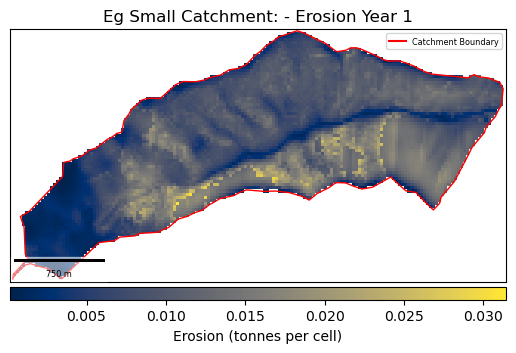

In [15]:
# To see a complete picture of sediment eroded across the catchment:
proj.plot_catchment_raster('Results', 'erosion_y1')

2026-04-17 11:22:11,966 - fire_impacts.pre.project - WARNING - project.plot_subcatchments() was asked to colour the map based on erosion_y1, but data table only had the following:
 Index(['sc_ID', 'peak_erosion_y1_mean', 'peak_erosion_y2_mean',
       'erosion_y1_sum', 'erosion_y2_sum', 'peak_delivered_y1_mean',
       'peak_delivered_y2_mean', 'delivered_y1_sum', 'delivered_y2_sum'],
      dtype='object'). plotting will proceed but with all symbols the same.
2026-04-17 11:22:11,967 - fire_impacts.pre.project - INFO - Column erosion_y1 not found; resolving to erosion_y1_sum.


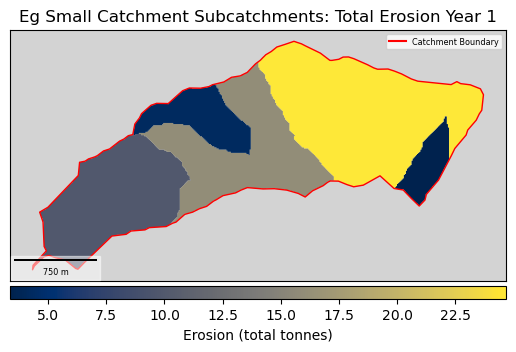

In [16]:
# To see the total sediment eroded across each subcatchment:
proj.plot_subcatchments(catchment=catchment_name, colour_col='erosion_y1')

2026-04-17 11:22:12,113 - fire_impacts.pre.project - INFO - Processing 1 catchments


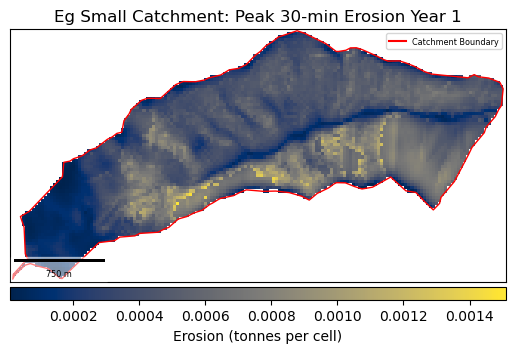

In [17]:
# To see the maximum erosion for any 30-minute period for each cell:
proj.plot_catchment_raster('Results', 'peak_erosion_y1')

2026-04-17 11:22:12,279 - fire_impacts.pre.project - WARNING - project.plot_subcatchments() was asked to colour the map based on peak_erosion_y1, but data table only had the following:
 Index(['sc_ID', 'peak_erosion_y1_mean', 'peak_erosion_y2_mean',
       'erosion_y1_sum', 'erosion_y2_sum', 'peak_delivered_y1_mean',
       'peak_delivered_y2_mean', 'delivered_y1_sum', 'delivered_y2_sum'],
      dtype='object'). plotting will proceed but with all symbols the same.
2026-04-17 11:22:12,280 - fire_impacts.pre.project - INFO - Column peak_erosion_y1 not found; resolving to peak_erosion_y1_mean.


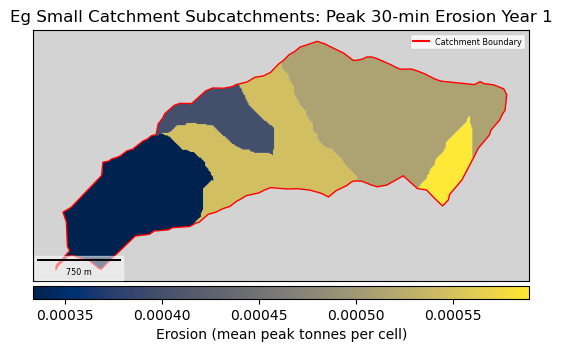

In [18]:
# To see the average maximum erosion in any 30-minute period across subcatchments:
proj.plot_subcatchments(catchment=catchment_name, colour_col='peak_erosion_y1')

Once we've predicted how much sediment has *eroded* from each cell, the final RUSLE step is to work out how much of that eroded sediment actually makes its way downhill and is *delivered* to the stream network.

2026-04-17 11:22:12,442 - fire_impacts.pre.project - INFO - Processing 1 catchments


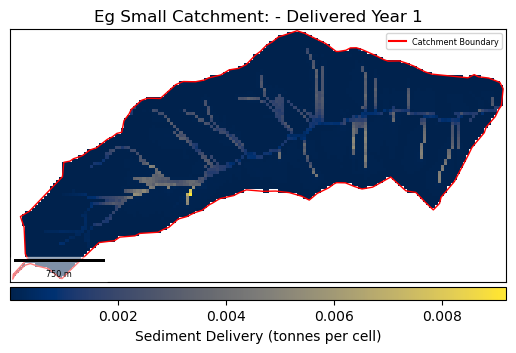

In [19]:
# Total sediment delivered to streams during the first year:
proj.plot_catchment_raster('Results', 'delivered_y1')

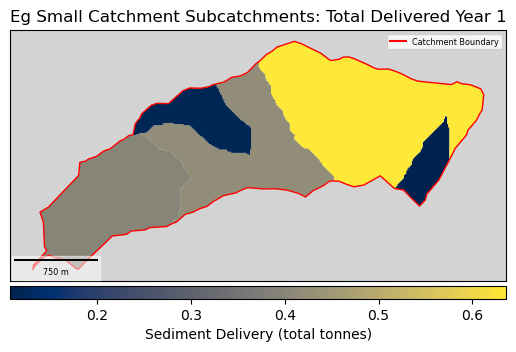

In [20]:
# Totals delivered from each subcatchment:
proj.plot_subcatchments(catchment=catchment_name, colour_col='delivered_y1_sum')

2026-04-17 11:22:12,759 - fire_impacts.pre.project - INFO - Processing 1 catchments


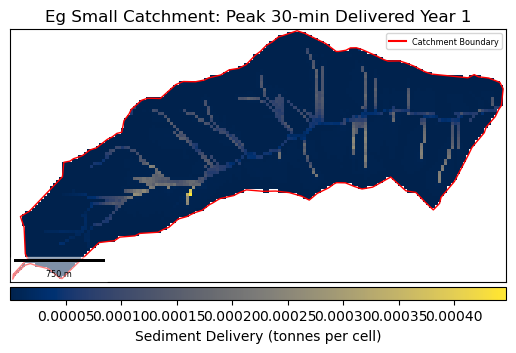

In [21]:
# Largest mass of sediment delivered during any 30-minute period for each cell:
proj.plot_catchment_raster('Results', 'peak_delivered_y1')

2026-04-17 11:22:12,925 - fire_impacts.pre.project - WARNING - project.plot_subcatchments() was asked to colour the map based on peak_delivered_y1, but data table only had the following:
 Index(['sc_ID', 'peak_erosion_y1_mean', 'peak_erosion_y2_mean',
       'erosion_y1_sum', 'erosion_y2_sum', 'peak_delivered_y1_mean',
       'peak_delivered_y2_mean', 'delivered_y1_sum', 'delivered_y2_sum'],
      dtype='object'). plotting will proceed but with all symbols the same.
2026-04-17 11:22:12,926 - fire_impacts.pre.project - INFO - Column peak_delivered_y1 not found; resolving to peak_delivered_y1_mean.


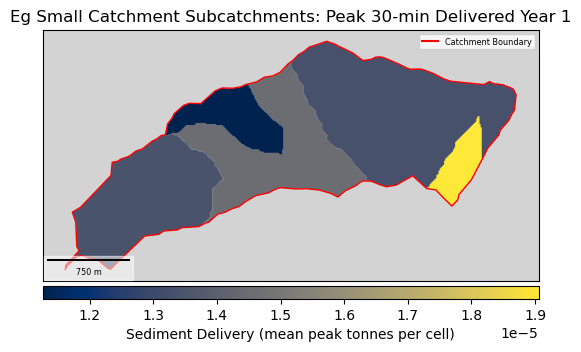

In [22]:
# Average maximum sediment delivered during any 30-minute period across each subcatchment:
proj.plot_subcatchments(catchment=catchment_name, colour_col='peak_delivered_y1')

## Debris Flow Simulation

Debris flow operates on headwaters only and uses 12 minute rainfall _intensity_ data.

The first thing we need to do is convert the rainfall *depth* values provided by pyraingen, to *intensity* values and then resample to 12-minute intervals


In [23]:
from fire_impacts.sim import convert_rainfall_depth_to_intensity

In [24]:
rainfall_intensity = convert_rainfall_depth_to_intensity(rainfall_data)
rainfall = aggregate_rainfall_data(rainfall_intensity,rain_data_start,rain_data_end,time_res='12min')
rainfall.rainfall

<xarray.DataArray 'rainfall' (time: 87600, replicate: 10)> Size: 7MB
array([[0.        , 0.25345266, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [2.37681413, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.96331   , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(87600, 10))
Coordinates:
  * replicate  (replicate) object 80B 'Simulation_0' ... 'Simulation_9'
  * time       (time) datetime64[ns] 701kB 2019-03-07 ... 2021-03-05T23:48:00
Attributes:
    units:    mm/h

In [25]:
# Extract and inspect one replicate:
rain_intensity_seq = rainfall.rainfall[:,9].to_pandas()
rain_intensity_seq

time
2019-03-07 00:00:00    0.0
2019-03-07 00:12:00    0.0
2019-03-07 00:24:00    0.0
2019-03-07 00:36:00    0.0
2019-03-07 00:48:00    0.0
                      ... 
2021-03-05 23:00:00    0.0
2021-03-05 23:12:00    0.0
2021-03-05 23:24:00    0.0
2021-03-05 23:36:00    0.0
2021-03-05 23:48:00    0.0
Freq: 12min, Name: rainfall, Length: 87600, dtype: float64

### Run the simulation

In [26]:
df_results = debris_flow(proj,rain_intensity_seq)

2026-04-17 11:22:40,086 - fire_impacts.pre.project - INFO - Processing 1 catchments
2026-04-17 11:22:40,087 - fire_impacts.sim.debris - WARNING - Rainfall data has no units attribute, assuming units are correct (mm/hr)
2026-04-17 11:22:40,096 - fire_impacts.pre.topography - INFO - Creating hydrologically-enforced DEM from \zz_TempDump\fire_impacts_example_project\Catchments\EgSmallCatchment_7899\Topography\DEM.tif
2026-04-17 11:22:40,099 - fire_impacts.pre.topography - INFO - Filling pits
2026-04-17 11:22:40,103 - fire_impacts.pre.topography - INFO - Filling depressions
2026-04-17 11:22:40,137 - fire_impacts.pre.topography - INFO - Resolving flats
2026-04-17 11:22:40,214 - fire_impacts.sim.debris - INFO - Existing flow direction raster found at \zz_TempDump\fire_impacts_example_project\Catchments\EgSmallCatchment_7899\Topography\Flow_direction.tif. Reading this in instead of computing new raster.
2026-04-17 11:22:40,224 - fire_impacts.sim.debris - INFO - Existing flow accumulation rast

### Viewing debris flow simulation results

A table of results for each headwater will be saved to the project's **DebrisFlow** folder. A separate table will also be created with the same results aggregated to subcatchments.

The easiest way to interpret the results is to use the built-in visualisation methods: `plot_headwaters()` and `plot_subcatchments()`.

> **Note**: For this example, and in many cases, rainfall intensity values might be below the threshold required to initiate a debris flow in any of the headwaters.

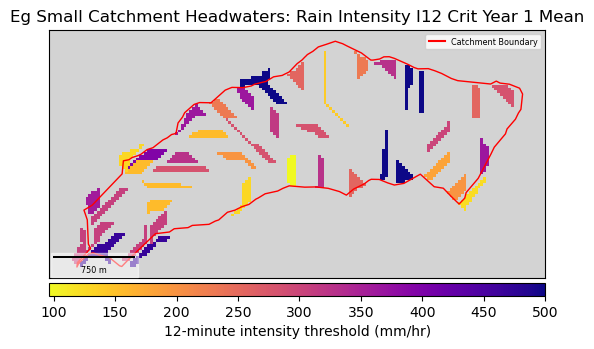

In [27]:
# To see the calculated critical thresholds for debris flow:
proj.plot_headwaters(catchment_name, 'I12_crit_mean_Year_1')

2026-04-17 11:22:40,800 - fire_impacts.pre.project - WARNING - project.plot_subcatchments() was asked to colour the map based on I12_crit_mean_Year_1, but data table only had the following:
 Index(['sc_ID', 'Year1_num_events', 'Year2_num_events',
       'Clay mass accumulation (kg)', 'Total erosion mass accumulation (kg)',
       'Sediment mass accumulation (kg)', 'I12_crit_mean_Year_1_min',
       'I12_crit_mean_Year_1_mean', 'I12_crit_mean_Year_2_min',
       'I12_crit_mean_Year_2_mean'],
      dtype='object'). plotting will proceed but with all symbols the same.
2026-04-17 11:22:40,802 - fire_impacts.pre.project - INFO - Column I12_crit_mean_Year_1 not found; resolving to I12_crit_mean_Year_1_min.


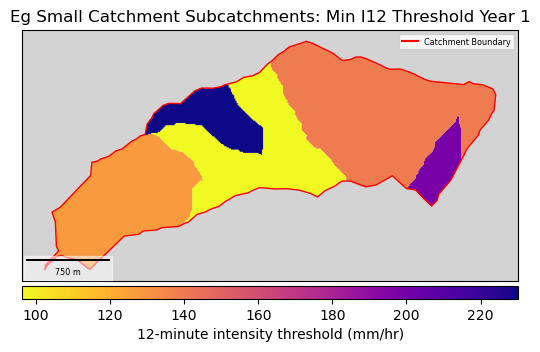

In [28]:
# The same, aggregated as the average threshold for each subcatchment:
proj.plot_subcatchments(catchment_name, 'DebrisFlow', 'I12_crit_mean_Year_1')

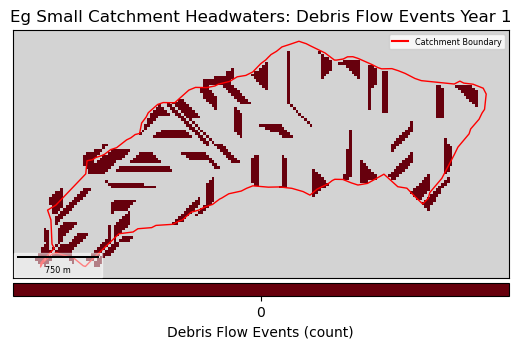

In [29]:
# To see the number of debris flow events in each headwater:
proj.plot_headwaters(catchment_name, 'Year1_num_events')

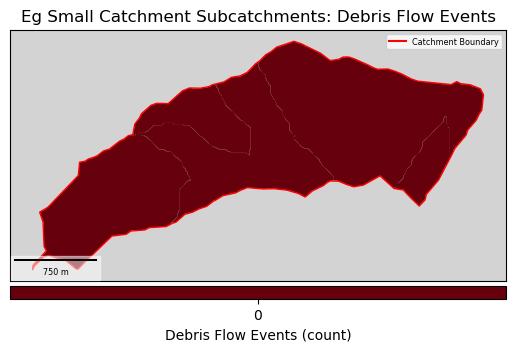

In [30]:
# And by subcatchment:
proj.plot_subcatchments(catchment_name, 'DebrisFlow', 'Year1_num_events')

2026-04-17 11:22:41,248 - fire_impacts.pre.project - WARNING - project.plot_subcatchments() was asked to colour the map based on mass, but data table only had the following:
 Index(['sc_ID', 'Year1_num_events', 'Year2_num_events',
       'Clay mass accumulation (kg)', 'Total erosion mass accumulation (kg)',
       'Sediment mass accumulation (kg)', 'I12_crit_mean_Year_1_min',
       'I12_crit_mean_Year_1_mean', 'I12_crit_mean_Year_2_min',
       'I12_crit_mean_Year_2_mean'],
      dtype='object'). plotting will proceed but with all symbols the same.


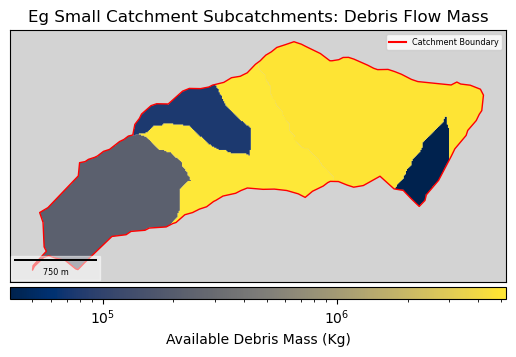

In [31]:
# Finally we can view the mass that would form part of a debris flow in each subcatchment:
proj.plot_subcatchments(catchment_name, 'DebrisFlow', 'mass')